In [5]:
import pandas as pd
df = pd.read_csv("sample_data/spotify_tracks (1).csv")
df = df.sample(n=5000,random_state=42).reset_index(drop=True)
df.head()

,track_id,track_name,artist_name,year,popularity,artwork_url,album_name,acousticness,danceability,duration_ms,...,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,track_url,language
0,5bQTuAxaBADfWk4vD8pCa5,"Adiye (From ""Kadal"")","A.R. Rahman, Sid Sriram",2019,15,https://i.scdn.co/image/ab67616d0000b273542d5b...,Rahman Rewind: Absolute Hits,0.4110,0.387,301973.0,...,2.0,0.0843,-5.684,1.0,0.0790,45.989,4.0,0.166,https://open.spotify.com/track/5bQTuAxaBADfWk4...,Unknown
1,4LrrOBgHGJNvRfmq2FRFBM,"Milne Hai Mujhse Aayi (From ""Aashiqui 2"")",Arijit Singh,2017,21,https://i.scdn.co/image/ab67616d0000b273c8d81c...,Best Of Shraddha Kapoor,0.0357,0.515,295798.0,...,11.0,0.1340,-5.467,0.0,0.0426,143.752,4.0,0.304,https://open.spotify.com/track/4LrrOBgHGJNvRfm...,Hindi
2,1P4CbDljM2EGHjaElwUwOa,The Vinciguerra Affair,Daniel Pemberton,2015,1,https://i.scdn.co/image/ab67616d0000b2738f5aee...,The Man from U.N.C.L.E. (Original Motion Pictu...,0.3100,0.772,202240.0,...,2.0,0.0890,-13.234,0.0,0.0320,120.008,4.0,0.475,https://open.spotify.com/track/1P4CbDljM2EGHja...,English
3,6sFq4k5MEWPafTW7GolQzP,Aadhi Bhagavan,"Ilaiyaraaja, Sriram Parthasarathy",2010,9,https://i.scdn.co/image/ab67616d0000b2735934ad...,Baba Pugazh Maalai,0.1320,0.670,324600.0,...,1.0,0.2980,-5.470,1.0,0.0267,91.008,4.0,0.346,https://open.spotify.com/track/6sFq4k5MEWPafTW...,Tamil
4,4wwi2d5XsvVDTA0rbTbOpQ,Beautiful,Amit Trivedi,2022,42,https://i.scdn.co/image/ab67616d0000b2739cfaea...,Goodbye (Original Motion Picture Soundtrack),0.5140,0.743,171375.0,...,2.0,0.1150,-7.922,1.0,0.0320,109.980,4.0,0.512,https://open.spotify.com/track/4wwi2d5XsvVDTA0...,Hindi


In [6]:
print("Missing values before preprocessing:")
print(df.isnull().sum())

Missing values before preprocessing:
track_id            0
track_name          0
artist_name         0
year                0
popularity          0
artwork_url         0
album_name          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
track_url           0
language            0
dtype: int64


In [7]:
from sklearn.preprocessing import StandardScaler

numerical_features = [
    "valence", "danceability", "energy", "tempo",
    "acousticness", "liveness", "speechiness", "instrumentalness"
]

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[numerical_features]), columns=numerical_features)

In [8]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(df_scaled, test_size=0.2, random_state=42)

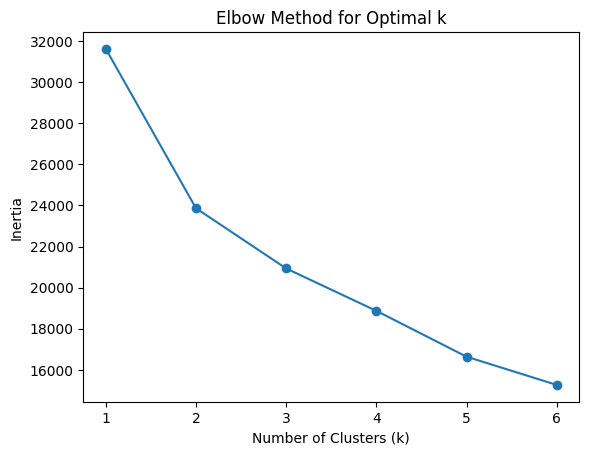

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_values = range(1, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=2)
    kmeans.fit(train_data)
    inertia.append(kmeans.inertia_)

plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

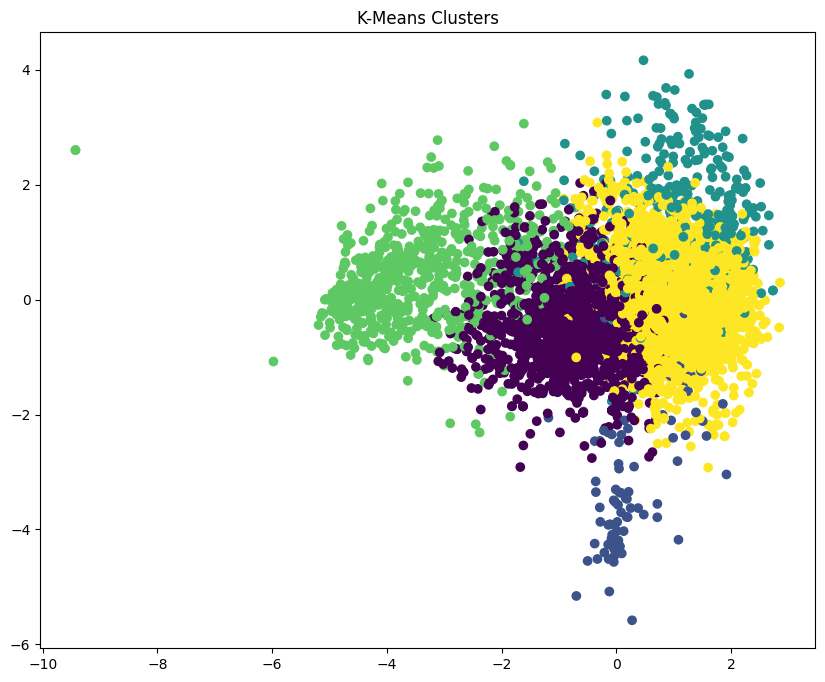

In [10]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df["Cluster"] = kmeans.fit_predict(df_scaled)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

plt.figure(figsize=(10,8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=df["Cluster"], cmap="viridis")
plt.title("K-Means Clusters")
plt.show()


In [11]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def recommend_songs(song_name, df, num_recommendations=5):

    song_cluster = df[df["track_name"] == song_name]["Cluster"].values[0]

    same_cluster_songs = df[df["Cluster"] == song_cluster]

    song_index = same_cluster_songs[same_cluster_songs["track_name"] == song_name].index[0]
    cluster_features = same_cluster_songs[numerical_features]
    similarity = cosine_similarity(cluster_features, cluster_features)

    similar_songs = np.argsort(similarity[song_index])[-(num_recommendations + 1):-1][::-1]
    recommendations = same_cluster_songs.iloc[similar_songs][["track_name", "year", "artists"]]

    return recommendations

In [12]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def recommend_songs(song_name, df, num_recommendations=5):
    if song_name not in df["track_name"].values:
        print(f"Error: Song '{song_name}' not found in the dataset.")
        return None

    input_song_row = df[df["track_name"] == song_name].iloc[0]
    input_song_cluster = input_song_row["Cluster"]
    input_song_language = input_song_row["language"]
    input_song_artist = input_song_row["artist_name"]
    original_song_index = input_song_row.name
    same_cluster_songs = df[df["Cluster"] == input_song_cluster].copy()

    filtered_songs = same_cluster_songs[
        (same_cluster_songs["language"] == input_song_language) &
        (same_cluster_songs["artist_name"] == input_song_artist)
    ]

    if len(filtered_songs) < num_recommendations + 1:
        print(f"Not enough recommendations found for exact language and artist match for '{song_name}'. Broadening to language match.")
        filtered_songs = same_cluster_songs[
            (same_cluster_songs["language"] == input_song_language)
        ]

    if len(filtered_songs) < num_recommendations + 1:
        print(f"Not enough recommendations found for language match for '{song_name}'. Broadening to all songs in the same cluster.")
        filtered_songs = same_cluster_songs

    song_row_in_filtered = filtered_songs[filtered_songs["track_name"] == song_name]
    if song_row_in_filtered.empty:
        print(f"Error: Input song '{song_name}' somehow filtered out. Returning None.")
        return None

    cluster_features = filtered_songs[numerical_features]

    positional_index_in_cluster = filtered_songs.index.get_loc(original_song_index)

    similarity = cosine_similarity(cluster_features, cluster_features)

    similar_songs_indices_in_filtered = np.argsort(similarity[positional_index_in_cluster])[-(num_recommendations + 1):-1][::-1]

    recommendations = filtered_songs.iloc[similar_songs_indices_in_filtered][["track_name", "year", "artist_name", "language"]]

    return recommendations

input_song =  f"The Vinciguerra Affair"
recommended_songs = recommend_songs(input_song, df, num_recommendations=5)

print(f"Songs similar to '{input_song}':")
if recommended_songs is not None:
    print(recommended_songs)
else:
    print(f"No recommendations found for '{input_song}'.")

Songs similar to 'The Vinciguerra Affair':
                       track_name  year       artist_name language
2003                       Eloped  2021  Daniel Pemberton  English
2611          Desperate Romantics  2006  Daniel Pemberton  English
3854                  Rocket Road  2024  Daniel Pemberton  English
4330  My Name Is... Miles Morales  2023  Daniel Pemberton  English
4720                     Game On!  2018  Daniel Pemberton  English


In [13]:
df.to_csv("clustered_df.csv")